**Contexte :**

Une entreprise possède plusieurs bâtiments équipés de capteurs IoT.
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression,
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure.
Après avoir utilisé NumPy pour manipuler les données numériques, Pandas pour importer, nettoyer
et analyser le dataset et Matplotlib pour réaliser des visualisations, l'étape suivante consiste à se
servir de Seaborn pour réaliser une analyse exploratoire plus riche des données.

**Alors d'abord nous allons importer le dataset**

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/mesures_capteurs.csv")

print(df.head())

  id_mesure           date_heure id_capteur batiment  temperature  humidite  \
0     M0413  2026-01-22 04:00:00       C005     B002        25.46     58.06   
1     M0290  2026-01-17 01:00:00       C002     B001        24.00     79.73   
2     M0077  2026-01-08 04:00:00       C005     B002        25.82     54.47   
3     M0079  2026-01-08 06:00:00       C007     B003        28.23     69.39   
4     M0183  2026-01-12 14:00:00       C003     B001        20.58     53.80   

   pression  consommation etat  
0   1008.95        287.28   OK  
1    993.39        116.20   OK  
2   1010.32        288.50   OK  
3   1019.62        136.65   OK  
4   1016.58        182.62   OK  


**Partie 1 – Distribution d'une variable avec histplot()**

1) Afficher la distribution des températures

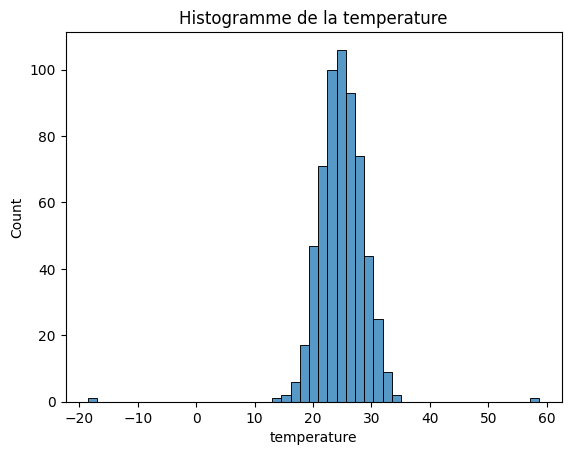

In [10]:
# alors pour afficher la distrubution d'une variable l'une des méthodes graphiques est l'histogramme 
# donc on vas utiliser le graphe histogramme en utilisant hisplot()

histogramme = sns.histplot(data=df , x ="temperature")

plt.title("Histogramme de la temperature")
plt.show()

2) Autour de quelle valeur les températures sont concentrées ?

Aprés observation et analyse de notre histogramme on peut conclure que les valeurs sont concentrées dans l'intervalle **[23 , 30]** et c'est une approximation par rapport à l'observation.

**3) La distribution semble-t-elle symétrique ?**

Non, la distribution est **légèrement asymétrique à gauche (asymétrie négative)** : on observe une traîne plus longue vers les basses températures, due à la présence de valeurs très basses (proches de -18 °C) qui tirent la distribution vers la gauche.

4) Existe-t-il des valeurs extrêmes ?

Oui. Le minimum observé est d'environ **-18,5 °C** et le maximum d'environ **58,7 °C**, très éloignés du reste des mesures qui se situent majoritairement entre 15 °C et 35 °C. Ce sont clairement des valeurs aberrantes (outliers), probablement liées à des défauts de capteurs plutôt qu'à des mesures physiques réelles.

5) Modifier le nombre de classes

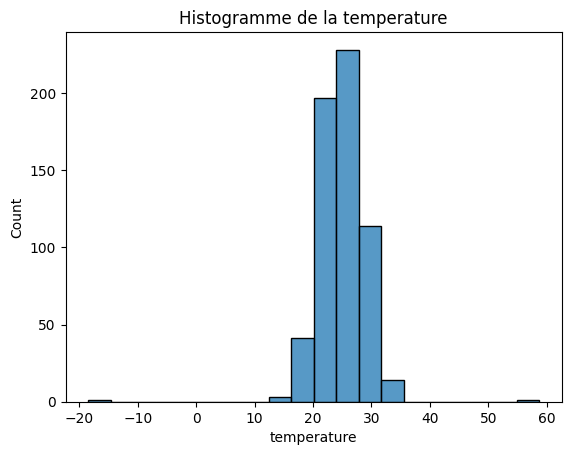

In [17]:
histogramme = sns.histplot(data=df , x ="temperature", bins=20)

plt.title("Histogramme de la temperature")
plt.show()

6) Afficher la distribution des températures par bâtiment

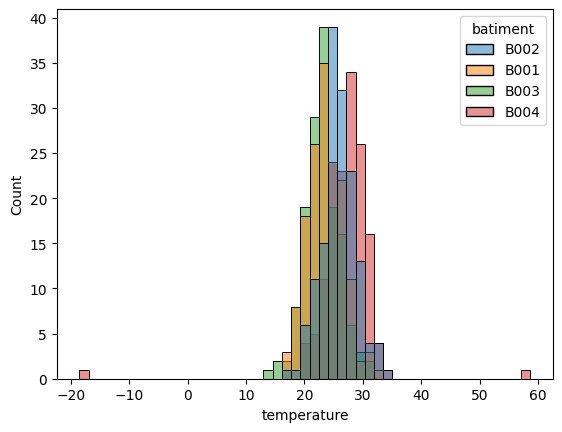

In [22]:
# Alors ici on dois d'abord regrouper les température par batiment et aprés traçer l'histogramme 

sns.histplot(data=df, x="temperature", hue="batiment", fill=True)

plt.show()



**Partie 2 – Distribution d'une variable avec kdeplot()**

1) Afficher la distribution des températures

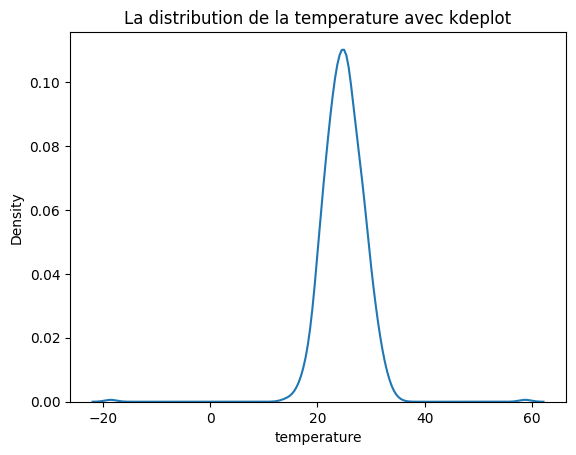

In [ ]:
# Pour afficher le graphe Kdeplot() c'est comme son nom il faut utiliser la méthode kdeplot() 
# qui prend en paramétre le dataframme et la colonne et fill qui est une variable booléen
# alors c'est False par défaut il ne vas pas mettre une couleur à l'intérieur du courbe
# si c'est True il remplie l'intérieur du graphe par une couleur

sns.kdeplot(data=df , x= "temperature" , fill=True)
plt.title("La distribution de la temperature avec kdeplot")

plt.show()


2) Afficher la distribution des températures par bâtiment

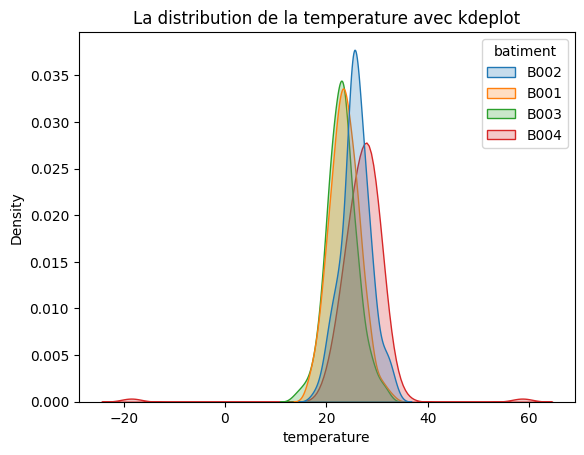

In [24]:

sns.kdeplot(data=df , x= "temperature",hue="batiment" , fill=True)
plt.title("La distribution de la temperature avec kdeplot")

plt.show()

**Partie 3 – Distribution d'une variable avec boxplot()**

1) Afficher la distribution des températures

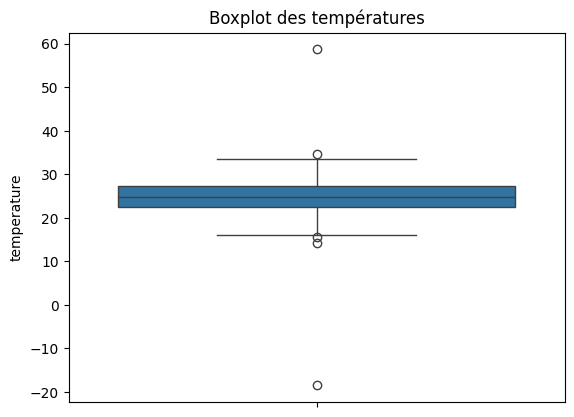

In [ ]:
# pour traçer un boxplot on utilise la méthode boxplot
# alors la petite remarque à faire c'est que on peut traçer le boxplot soit par rapport à l'axe des abcisse (x)
# ou l'axe des ordonnées (y)

sns.boxplot(data= df , y="temperature")
plt.title("Boxplot des températures")


plt.show()

2) Afficher la distribution des températures par bâtiment

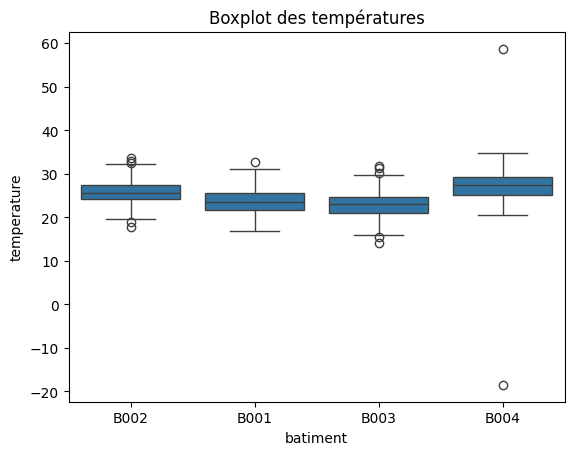

In [ ]:
# Alors j'ai omis de l'expliquer en haut mais pour afficher la variation d'une variable1 par une autre variable2
# pour ce faire on utilise les axes 
# 1) axe des abcisses nous aurons la variable2
# 2) axe des ordonnées nous aurons la variable1
sns.boxplot(data= df , x="batiment", y="temperature")
plt.title("Boxplot des températures")


plt.show()

3) Pour chaque bâtiment nous allons determiner,

a) la médiane ?

In [31]:
df.groupby("batiment")["temperature"].median()

batiment
B001    23.540
B002    25.670
B003    23.045
B004    27.535
Name: temperature, dtype: float64

b) quelle est la dispersion ?

In [32]:
# la dispersion correspond a l'ecart-type qui est calculer grace à la méthode std
df.groupby("batiment")["temperature"].std()


batiment
B001    2.961211
B002    2.951828
B003    2.983902
B004    5.367361
Name: temperature, dtype: float64

c) les valeurs extrêmes

In [ ]:
# les valeurs extrémes sont le minimum et le maximum

df.groupby("batiment")["temperature"].agg(["min" ,"max"])




,min,max
batiment,,
B001,16.77,32.72
B002,17.67,33.60
B003,14.11,31.74
B004,-18.50,58.70


4) quels bâtiments ont les valeurs les plus extrêmes ?

C'est le bâtiment **B004** qui présente les valeurs les plus extrêmes en amplitude (température minimale d'environ -18,5 °C et maximale d'environ 58,7 °C), bien au-delà des bornes normales des autres bâtiments. B002 et B003 ont davantage de points identifiés comme outliers par la règle de l'IQR, mais ceux-ci restent d'amplitude modérée comparés à B004.

**Partie 4 – Distribution d'une variable avec violinplot()**

1) Afficher la distribution des températures

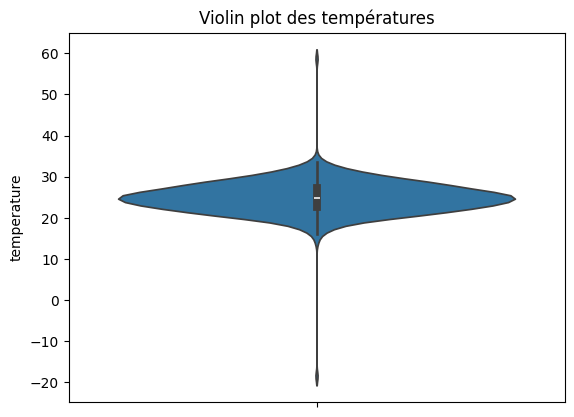

In [ ]:
# alors il faut utlisier la méthode violinplot avec comme paramétre le data et la colonne soit en abcisse ou en ordonnée
sns.violinplot(data=df , y="temperature")

plt.title("Violin plot des températures")

plt.show()

2) Afficher la distribution des températures par bâtiment

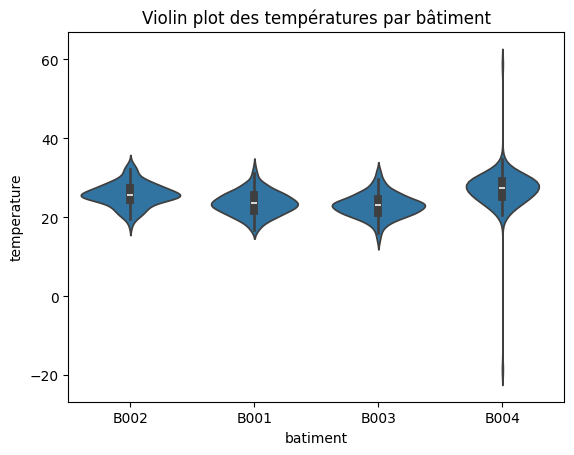

In [47]:
sns.violinplot(data=df ,x="batiment", y="temperature")

plt.title("Violin plot des températures par bâtiment")

plt.show()

3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box
plot ?

Le `boxplot()` ne montre que des statistiques résumées (médiane, quartiles, valeurs extrêmes), alors que le `violinplot()` affiche en plus la **forme complète de la distribution** (via une estimation de densité, comme le kdeplot) de chaque côté du "violon". Cela permet de voir directement si une distribution est unimodale ou multimodale, où se trouve la concentration des valeurs, et l'asymétrie de la distribution — des informations invisibles sur un simple boxplot.

**Partie 5 – Comptage des catégories avec countplot()**

1) Afficher le nombre de mesures par état ?

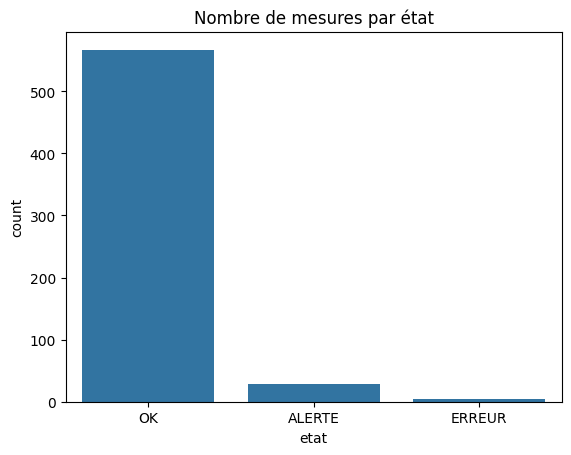

In [54]:
sns.countplot(data=df, x="etat")

plt.title("Nombre de mesures par état")
plt.show()

2) Afficher le nombre de mesures par bâtiment

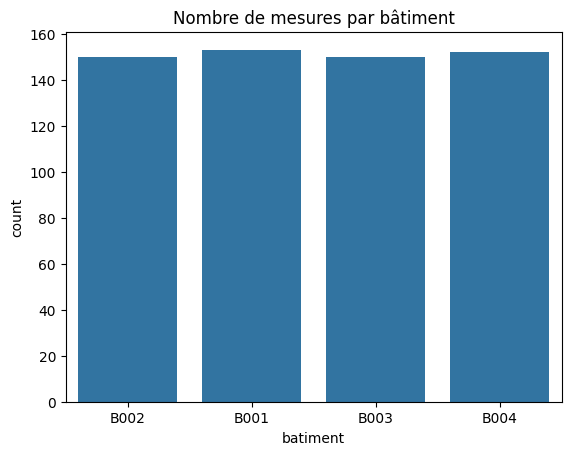

In [55]:
sns.countplot(data=df, x="batiment")

plt.title("Nombre de mesures par bâtiment")
plt.show()

**Une petite observation**

Le nombre de mesures est assez équilibré entre les 4 bâtiments (entre 146 et 153 mesures chacun).


3) Afficher les états des capteurs par bâtiment pour identifier

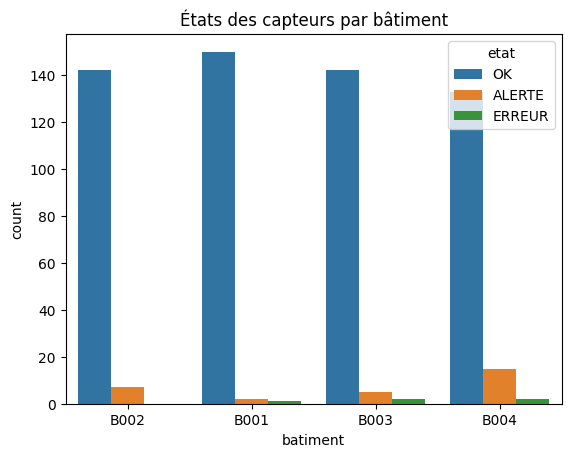

In [56]:
sns.countplot(data=df, x="batiment", hue="etat")
plt.title("États des capteurs par bâtiment")
plt.show()

**a) Bâtiment avec le plus de mesures en état OK :** B001 (150 mesures OK).

**b) Bâtiment avec le plus de mesures en ALERTE :** B004 (15 mesures en alerte, nettement plus que les autres).

**c) Bâtiment avec le plus de mesures en ERREUR :** B003 et B004 sont à égalité avec 2 mesures en erreur chacun (B001 en a 1, B002 aucune).

On remarque que B004, qui a déjà les températures les plus extrêmes, est aussi le bâtiment avec le plus d'alertes : il mérite une attention particulière (capteurs à vérifier).

**Partie 6 – Relation entre deux variables avec scatterplot()**

1) Etudier graphiquement la relation entre température et consommation

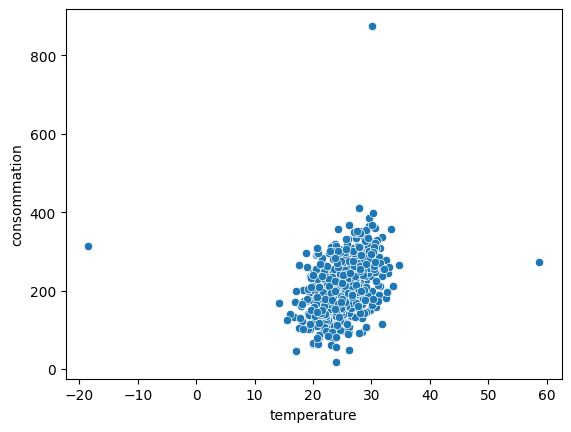

In [ ]:
# pour ce faire nous allons traçer le nuage de point entre la température et la consommation

sns.scatterplot(data=df , x="temperature" , y="consommation")

plt.title("Température vs Consommation")
plt.show()

2) Etudier graphiquement la relation entre température et consommation par bâtiment

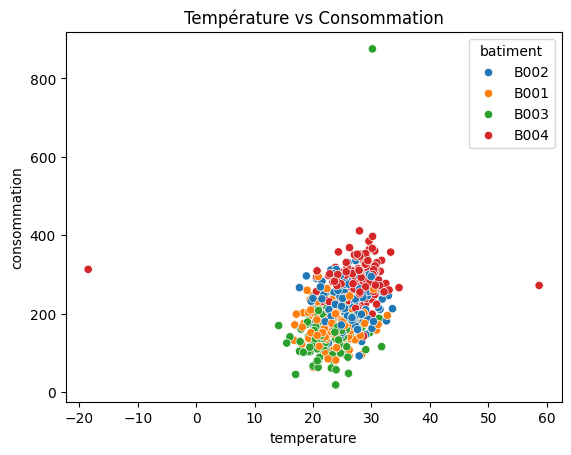

In [58]:
# bon il faut juste mettre le hue pour lui dire de regrouper
sns.scatterplot(data=df , x="temperature" , y="consommation" , hue="batiment")

plt.title("Température vs Consommation")
plt.show()

**petite observation**

On observe une tendance positive globale : plus la température est élevée, plus la consommation énergétique a tendance à augmenter (probablement lié à l'usage de climatisation/chauffage). Cette tendance se retrouve dans chacun des bâtiments, avec des niveaux de consommation qui diffèrent néanmoins d'un bâtiment à l'autre.

3) Modifier la taille des points

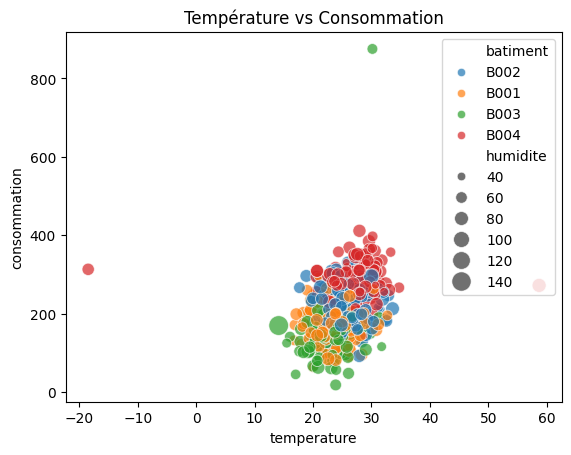

In [ ]:
# pour modifier la taille des points on utilise 

sns.scatterplot(data=df , x="temperature", y="consommation", hue="batiment", size="humidite", sizes=(20, 200), alpha=0.7)

plt.title("Température vs Consommation et la taille=Humidité")
plt.show()

**Partie 7 – Régression avec regplot()**

Etudier graphiquement une tendance entre température et consommation

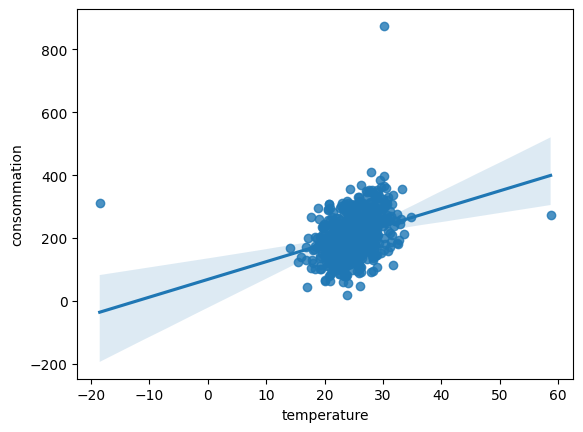

In [ ]:
sns.regplot(data=df , x="temperature" , y="consommation")
plt.title("Régression linéaire : Température vs Consommation")
plt.show()

**Partie 8 – Régression avec lmplot()**

Etudier graphiquement une tendance entre température et consommation par bâtiment

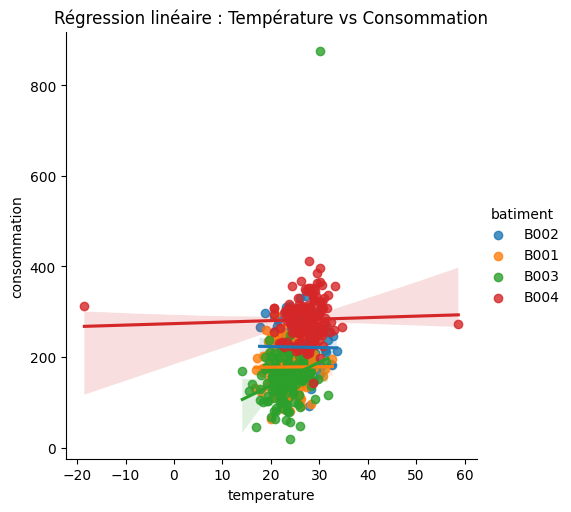

In [ ]:
sns.lmplot(data=df , x="temperature" , y="consommation" , hue="batiment")
plt.title("Régression par bâtiment : Température vs Consommation")
plt.show()

**Petite observation**

`lmplot()` permet de superposer une droite de régression par sous-groupe. On constate que la relation positive entre température et consommation est présente dans tous les bâtiments, mais avec des pentes et des niveaux de base différents : certains bâtiments (comme B004) ont une consommation globalement plus sensible aux variations de température que d'autres.

**Partie 9 – Corrélations**

1) Utiliser Pandas pour calculer les corrélations entre température, humidité, pression et
consommation.

In [70]:
# on utilise la fonction corr pour calculer la correlation
corr = df[["temperature", "humidite", "pression", "consommation"]].corr()
corr

,temperature,humidite,pression,consommation
temperature,1.000000,-0.006126,0.061283,0.317048
humidite,-0.006126,1.000000,0.045242,-0.046061
pression,0.061283,0.045242,1.000000,0.056051
consommation,0.317048,-0.046061,0.056051,1.000000


2) Afficher la matrice de corrélation obtenue avec Pandas

In [71]:
print(corr.round(3))

              temperature  humidite  pression  consommation
temperature         1.000    -0.006     0.061         0.317
humidite           -0.006     1.000     0.045        -0.046
pression            0.061     0.045     1.000         0.056
consommation        0.317    -0.046     0.056         1.000


3) Afficher le heatmap de la corrélation pour identifier :

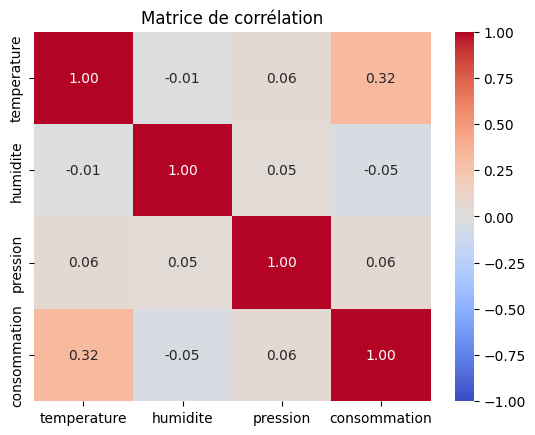

In [76]:
# pour afficher le headmap on utilise la méthode headmap intégrer dans seaborn

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

**a) Corrélations positives :** la plus notable est celle entre **température et consommation** (≈ 0,32) : une corrélation positive modérée. Les autres paires (température/pression ≈ 0,06, humidité/pression ≈ 0,05) sont positives mais très faibles.

**b) Corrélations négatives :** température/humidité (≈ -0,006) et humidité/consommation (≈ -0,05) sont négatives mais quasiment nulles.

**c) Corrélations proches de zéro :** la quasi-totalité des paires impliquant l'humidité et la pression sont proches de 0, ce qui indique une absence de relation linéaire avec les autres variables.

**d) Variables qui semblent le plus fortement liées :** **température et consommation** sont les deux variables les plus corrélées du jeu de données, même si le lien reste modéré (≈ 0,32) plutôt que fort.


**Partie 10 – Analyse multivariée avec pairplot()**

En considérant la température, l’humidité, la pression et la consommation, réaliser un graphique qui
affiche simultanément les distributions individuelles et les scatter plots entre variables.

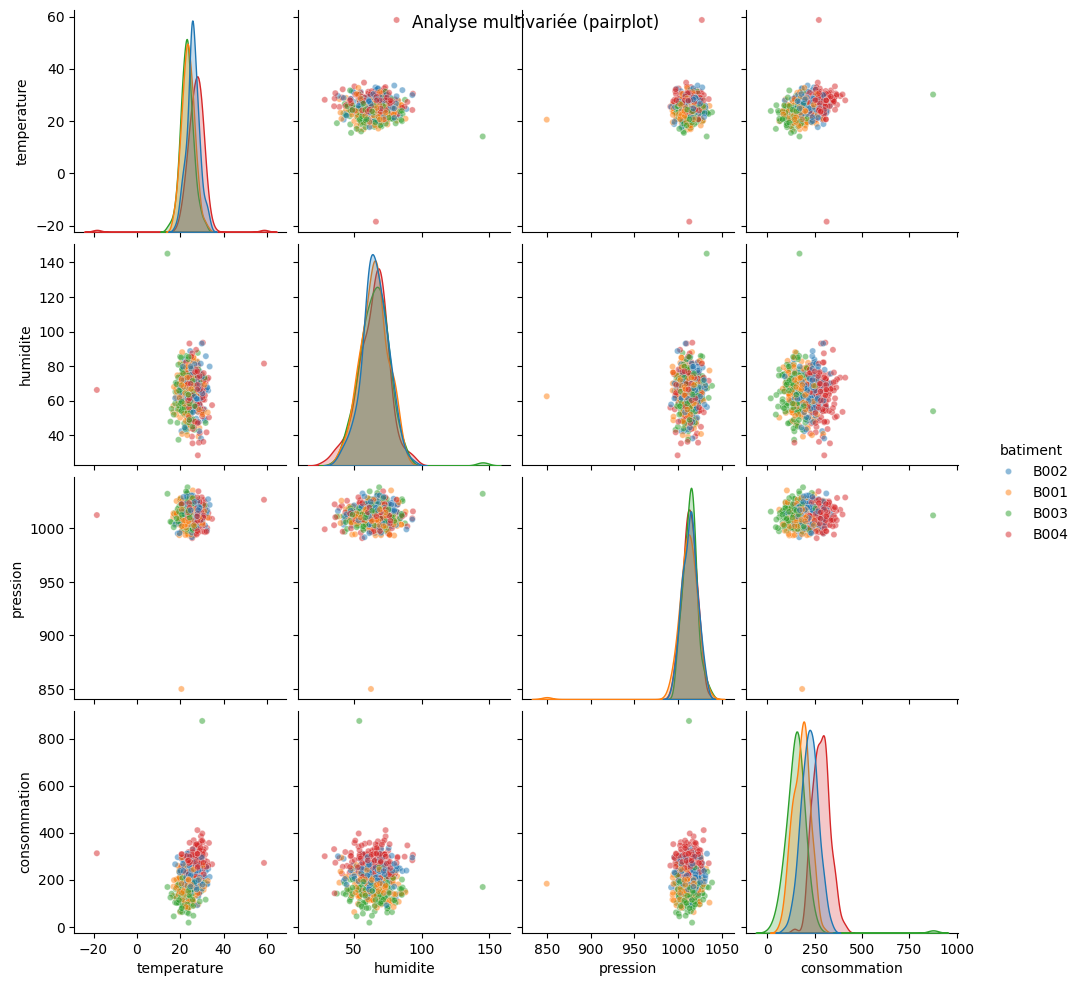

In [ ]:
# alors ici j'ai mis la variable batiment dans le df pour que je puisse faire des distinction des points avec hue par batiment 
# sans cela ça vas afficher une erreur
sns.pairplot(df[["temperature", "humidite", "pression", "consommation", "batiment"]], hue="batiment", diag_kind="kde", plot_kws={"alpha":0.5, "s":20})
plt.suptitle("Analyse multivariée (pairplot)")
plt.show()

**Partie 11 : Sauvegarde des graphiques**

Sauvegarder les graphiques dans le sous-dossier exports

In [ ]:
# pour sauvegarder avec seaborn on utilise savefig(chemin du dossier ou exporter et nom de l'image , qualité)


# Exemple : alors ici j'ai régénérer et sauvegarder quelques graphiques clés en PNG et PDF dans le dossier ../exports

# 1) Histogramme des températures
fig, ax = plt.subplots()
sns.histplot(data=df, x="temperature", kde=True, ax=ax)
ax.set_title("Distribution des températures")
fig.savefig("../exports/temperature.png", dpi=150)
plt.close(fig)

# 2) Boxplot par bâtiment
fig, ax = plt.subplots()
sns.boxplot(data=df, x="batiment", y="temperature")
ax.set_title("Températures par bâtiment")
fig.savefig("../exports/temperature_boxplot_batiment.png", dpi=150)
plt.close(fig)

# 3) Heatmap des corrélations
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=ax)
ax.set_title("Matrice de corrélation")
fig.savefig("../exports/correlation_heatmap.png", dpi=150)
plt.close(fig)

# 4) Scatter température / consommation
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", ax=ax)
ax.set_title("Température vs Consommation")
fig.savefig("../exports/temperature_vs_consommation.png", dpi=150)
plt.close(fig)

print("Graphiques exportés dans le dossier exports/")


Graphiques exportés dans le dossier exports/
